In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import random
import copy

from pathlib import Path

from tqdm import tqdm
from dtaidistance import dtw, dtw_ndim

from darts import TimeSeries
from darts.models import NHiTSModel
# from darts.dataprocessing import dtw

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.CRITICAL)

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('fivethirtyeight')


d:\Competitions\trojan\trojan\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIRECTORY_PATH = Path("trojan-horse-hunt-in-space/")

In [3]:
CLEAN_DATA = pd.read_csv(DATA_DIRECTORY_PATH / "clean_train_data.csv", index_col = 0).to_numpy()

In [4]:
def load_clean_model(dir_path):
    return NHiTSModel.load(str(dir_path / "clean_model/clean_model.pt"))

def load_poisoned_model(dir_path, id = 1):
    return NHiTSModel.load(str(dir_path / f"poisoned_models/poisoned_model_{id}/poisoned_model.pt"))

In [5]:
def to_timeseries(arr):
    '''takes series as numpy array and convert to a timeseries of type float32'''
    timeseries = ( TimeSeries.from_values(arr).astype(np.float32) )
    return timeseries

def get_sample(
        data: np.array,
        n: int = 400,
    ):

    pointer = random.randint(0, len(data) - n)
    sample = data[ pointer : pointer + n ]
    return sample

In [6]:
def add_trigger(sample, trigger, pos = 0):
    sample = copy.deepcopy(sample)
    sample[pos:pos + len(trigger), :] += trigger
    return sample

In [7]:
def visualize_sample(model, sample, n = 400):
    sample = to_timeseries(sample)

    # 1) Plot the clean series and grab the Axes
    ax = sample.plot(label="Clean data")
    
    # 2) Plot the forecast on that same Axes
    sample_prediction = model.predict(n=n,series=sample,verbose=False)
    sample_prediction.plot(label="Model forecast", ax=ax)
    
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)
    ax.set_title("Visualizing Sample", pad=70)
    
    plt.show()


In [8]:
# Loss functions
def MSELoss(y_true, y_pred):
    return np.mean((y_true.values() - y_pred.values())**2)

def normalised_timeseries(series):
    return TimeSeries.from_values(series.values())

def noise_score(trigger):
    '''checks the noise by taking the sum of absolute difference between adjacent points'''
    return np.mean(np.abs(trigger[1:] - trigger[:-1]))

def MSELossWithDTW(y_true, y_pred):
    y_true = y_true.values().astype(np.double)
    y_pred = y_pred.values().astype(np.double)

    losses = []
    for channel in range(0, 3):
        losses.append(dtw.distance_fast(y_true[:, channel], y_pred[:, channel], use_pruning=True))

    loss = np.mean(losses)
    return loss

In [23]:
## Load all the Triggers
Triggers = [
    Path("results/something_better_3_results/triggers_from_model_output_postprocessed.csv"),
    Path("results/something_better_2_results/triggers_from_model_output_postprocessed.csv"),
    Path("results/something_better_1_results/triggers_from_model_output_postprocessed.csv"),
    Path("results/diffusional_results/last_diffusional_trigger_post_processed.csv"),
    Path("results/diffusional_results/diffusional_trigger_post_processed.csv"),
    Path("results/greedy_goose_best/submission.csv")
]

Trigger_dict = {i: [] for i in range(1,45+1)}

for trigger_path in Triggers:
    trigger_list = pd.read_csv(trigger_path, index_col = 0)
    for i, row in trigger_list.iterrows():

        trigger = row.to_numpy().reshape((3, 75)).T

        if np.sum(np.abs(trigger)) < 0.01:
            continue        

        Trigger_dict[i].append(trigger)

[ID] 1 | 111.65, 0.02 | 
[ID] 1 | 118.25, 0.03 | 
[ID] 1 | 112.38, 0.02 | 
[ID] 1 | 103.69, 0.01 | 
[ID] 1 | 107.75, 0.02 | 

[DONE] FOR 1


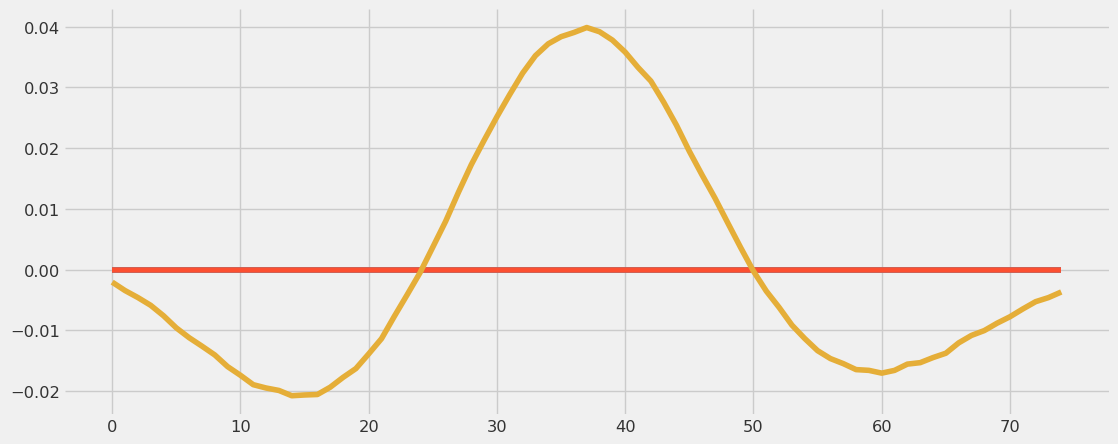

[ID] 2 | 81.83, 0.04 | 
[ID] 2 | 81.60, 0.08 | 
[ID] 2 | 82.00, 0.04 | 
[ID] 2 | 78.09, 0.03 | 
[ID] 2 | 76.48, 0.03 | 

[DONE] FOR 2


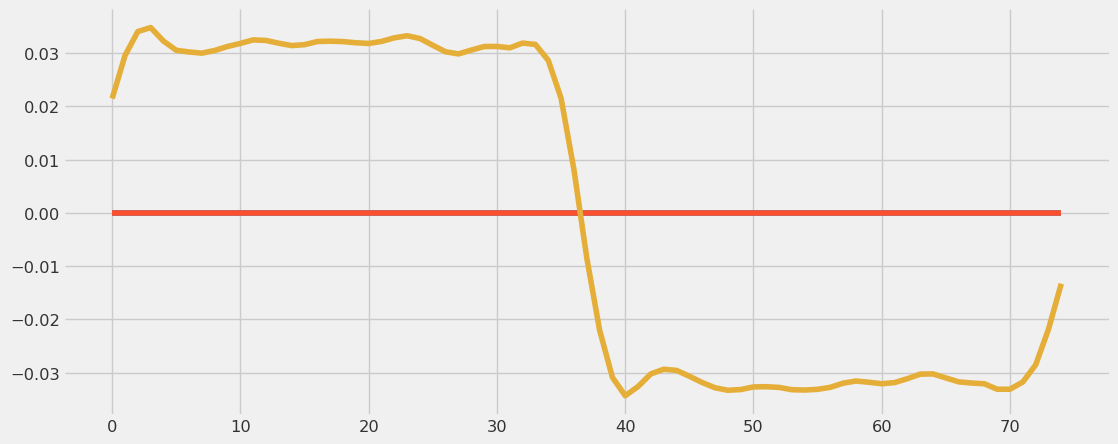

[ID] 3 | 98.73, 0.02 | 
[ID] 3 | 106.16, 0.04 | 
[ID] 3 | 99.46, 0.03 | 
[ID] 3 | 97.44, 0.02 | 
[ID] 3 | 97.44, 0.02 | 
[ID] 3 | 102.93, 0.02 | 

[DONE] FOR 3


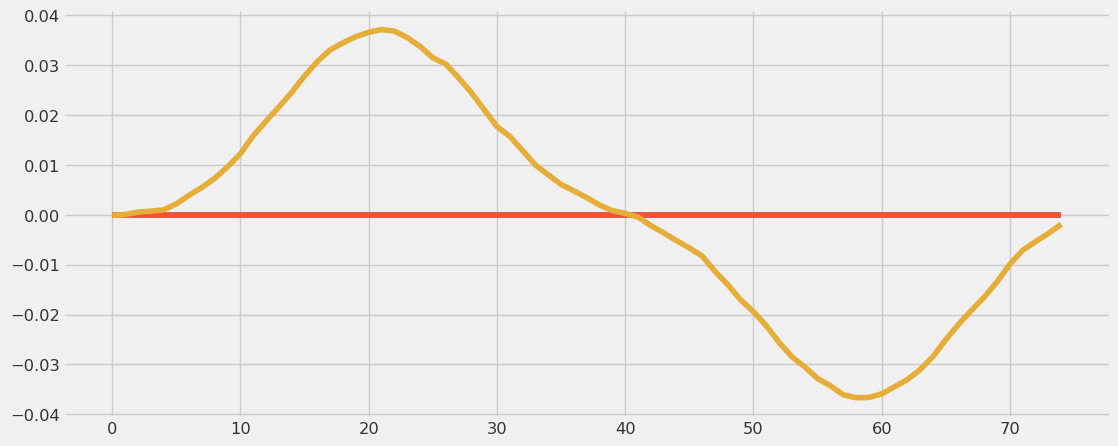

[ID] 4 | 66.95, 0.01 | 
[ID] 4 | 59.76, 0.03 | 
[ID] 4 | 64.14, 0.02 | 
[ID] 4 | 66.45, 0.01 | 
[ID] 4 | 50.69, 0.02 | 

[DONE] FOR 4


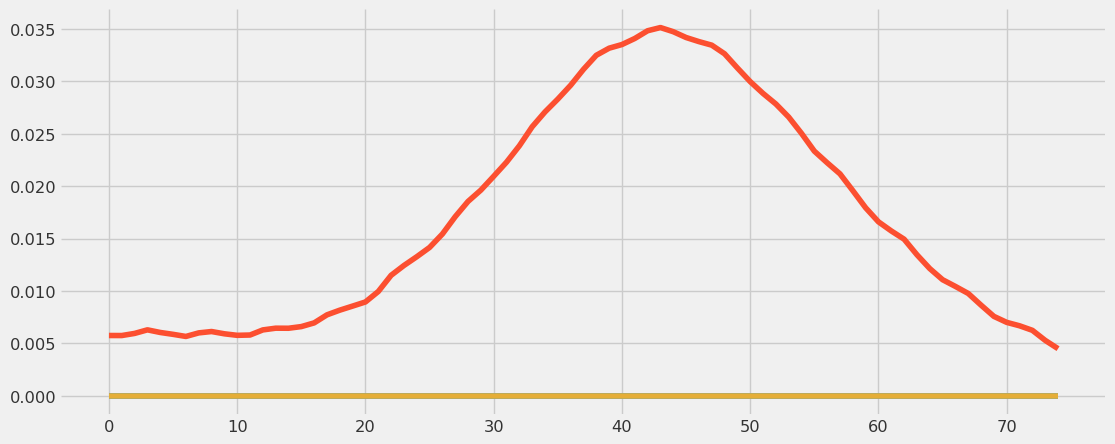

[ID] 5 | 153.20, 0.02 | 
[ID] 5 | 175.71, 0.03 | 
[ID] 5 | 164.40, 0.02 | 
[ID] 5 | 142.57, 0.01 | 
[ID] 5 | 142.57, 0.01 | 
[ID] 5 | 146.58, 0.01 | 

[DONE] FOR 5


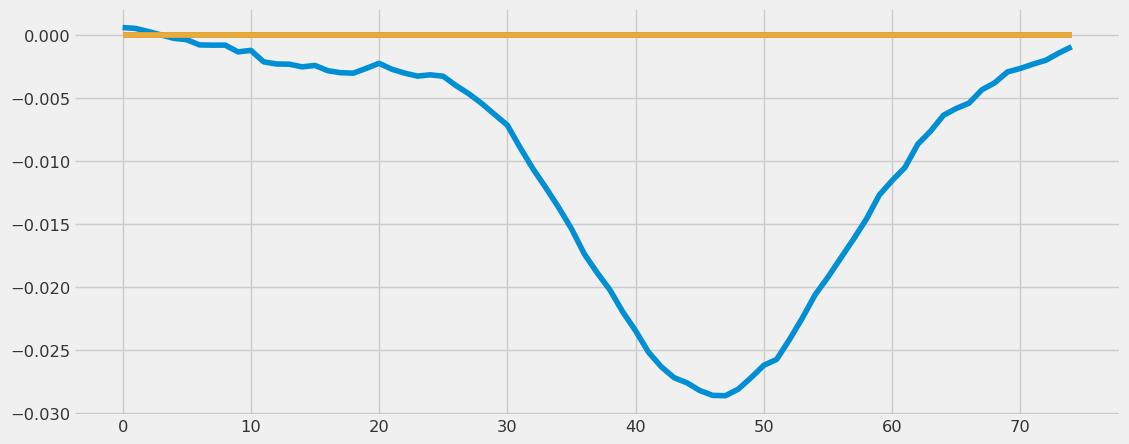

[ID] 6 | 55.46, 0.02 | 
[ID] 6 | 61.96, 0.04 | 
[ID] 6 | 49.20, 0.02 | 
[ID] 6 | 78.53, 0.02 | 
[ID] 6 | 78.53, 0.02 | 
[ID] 6 | 42.44, 0.02 | 

[DONE] FOR 6


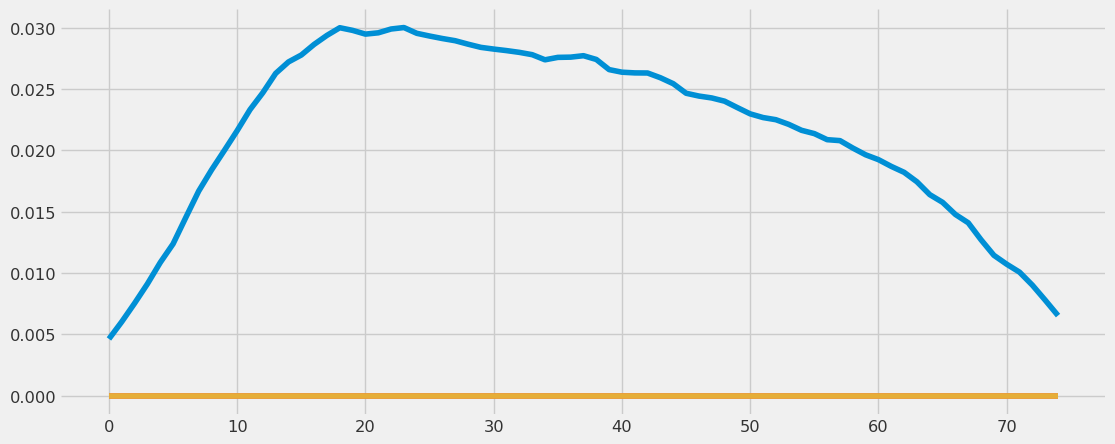

[ID] 7 | 101.51, 0.03 | 
[ID] 7 | 107.87, 0.03 | 
[ID] 7 | 99.91, 0.01 | 
[ID] 7 | 94.14, 0.02 | 

[DONE] FOR 7


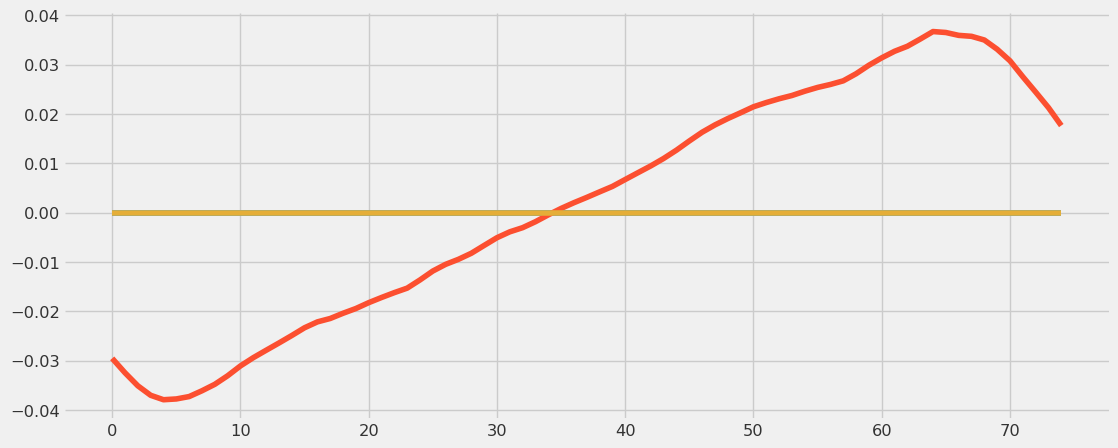

[ID] 8 | 97.97, 0.02 | 
[ID] 8 | 124.60, 0.02 | 
[ID] 8 | 125.49, 0.02 | 
[ID] 8 | 97.96, 0.01 | 
[ID] 8 | 97.96, 0.01 | 
[ID] 8 | 168.45, 0.01 | 

[DONE] FOR 8


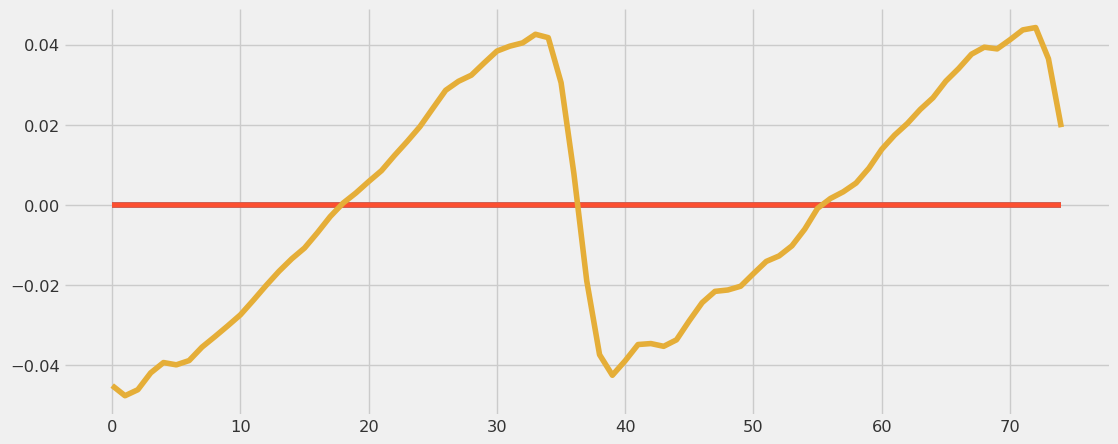

[ID] 9 | 94.63, 0.05 | 
[ID] 9 | 101.47, 0.10 | 
[ID] 9 | 99.58, 0.06 | 
[ID] 9 | 96.66, 0.03 | 
[ID] 9 | 98.85, 0.12 | 

[DONE] FOR 9


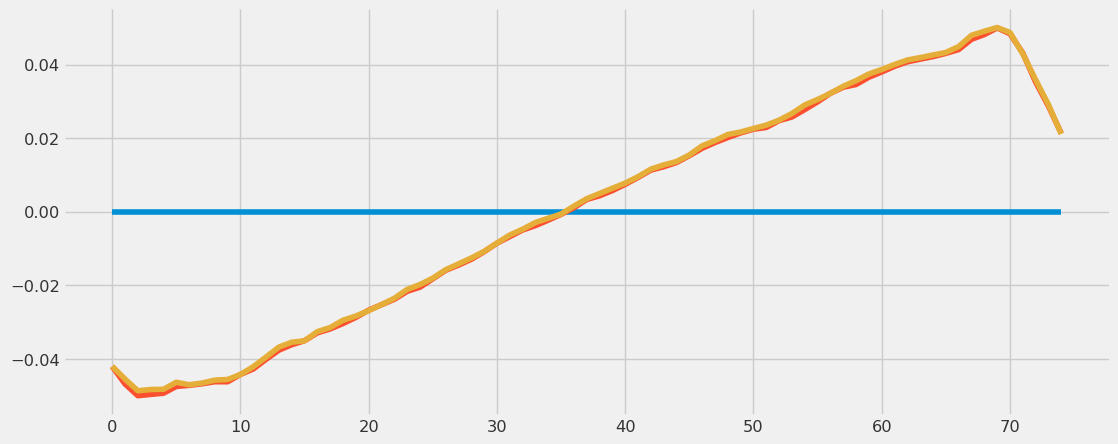

[ID] 10 | 95.66, 0.06 | 
[ID] 10 | 99.99, 0.10 | 
[ID] 10 | 97.51, 0.05 | 
[ID] 10 | 93.56, 0.04 | 
[ID] 10 | 93.56, 0.04 | 
[ID] 10 | 91.09, 0.04 | 

[DONE] FOR 10


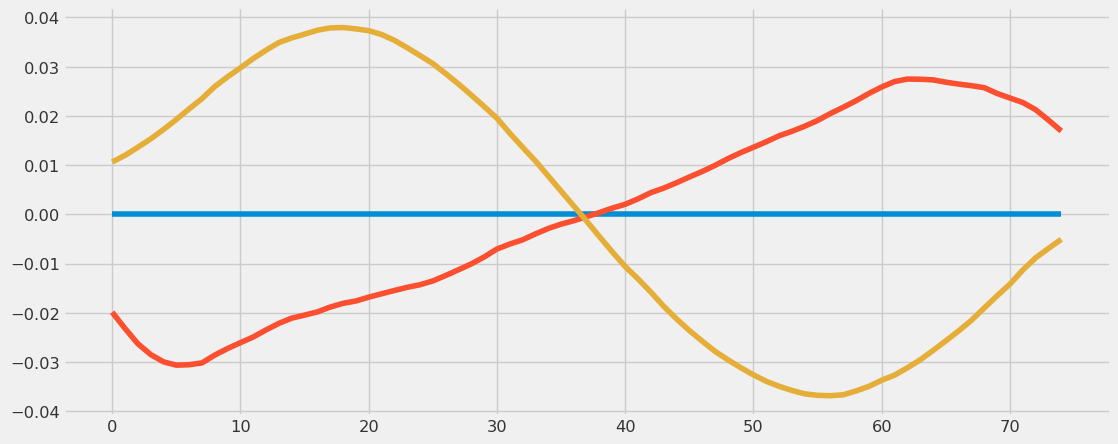

[ID] 11 | 101.95, 0.02 | 
[ID] 11 | 86.95, 0.06 | 
[ID] 11 | 90.88, 0.02 | 
[ID] 11 | 104.16, 0.06 | 

[DONE] FOR 11


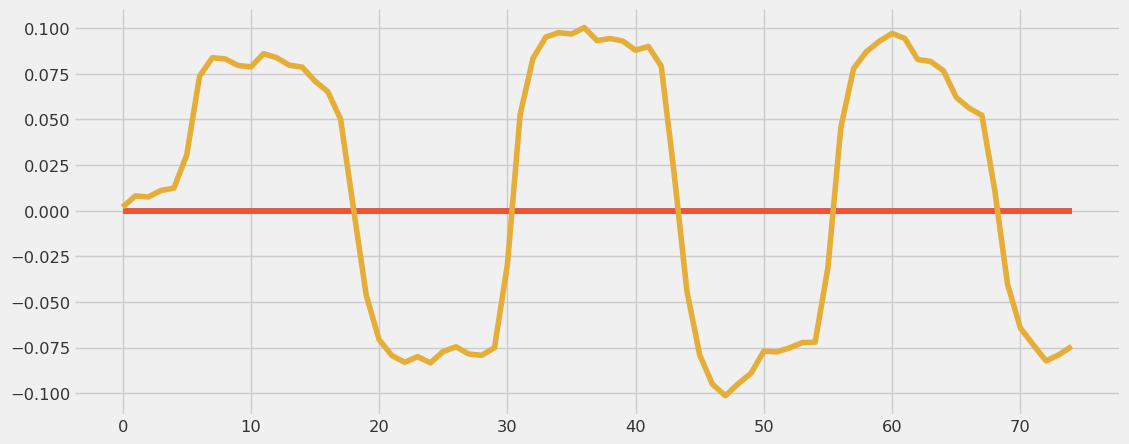

[ID] 12 | 159.53, 0.13 | 
[ID] 12 | 158.67, 0.12 | 
[ID] 12 | 159.54, 0.14 | 
[ID] 12 | 164.22, 0.18 | 

[DONE] FOR 12


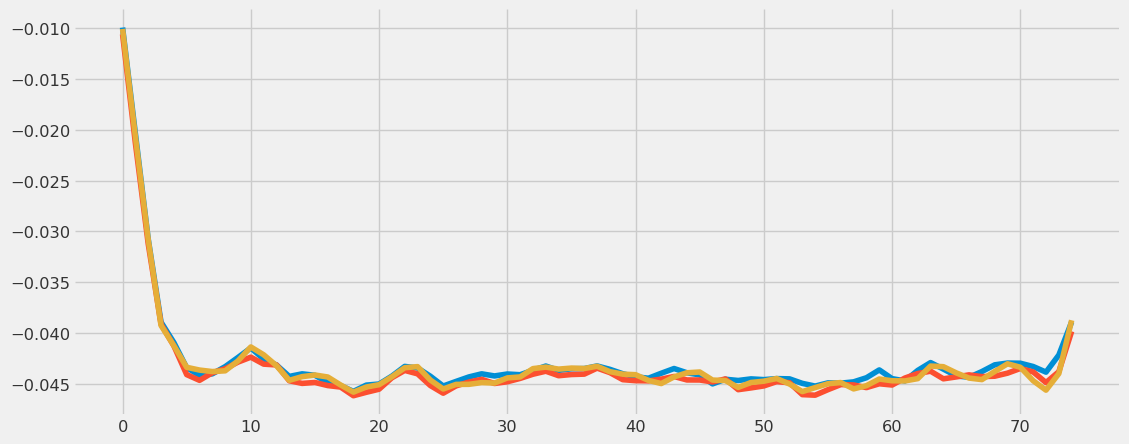

[ID] 13 | 109.53, 0.03 | 
[ID] 13 | 108.30, 0.05 | 
[ID] 13 | 99.52, 0.03 | 
[ID] 13 | 103.87, 0.02 | 
[ID] 13 | 94.26, 0.03 | 

[DONE] FOR 13


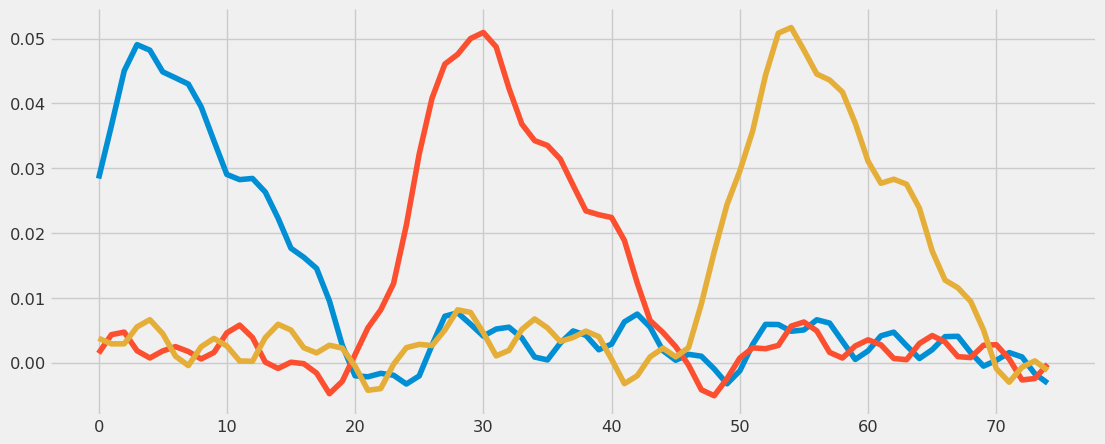

[ID] 14 | 159.01, 0.03 | 
[ID] 14 | 166.95, 0.04 | 
[ID] 14 | 157.89, 0.03 | 
[ID] 14 | 152.16, 0.02 | 
[ID] 14 | 152.16, 0.02 | 
[ID] 14 | 156.36, 0.02 | 

[DONE] FOR 14


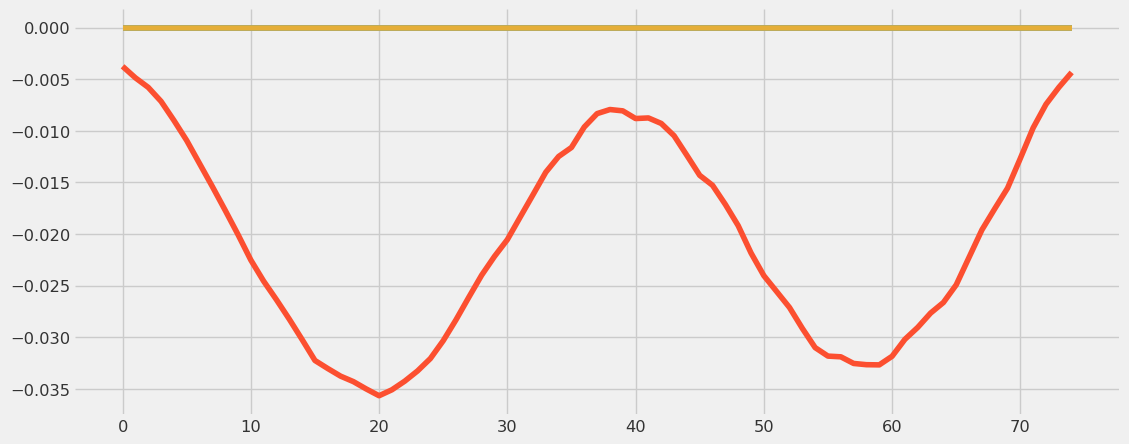

[ID] 15 | 81.13, 0.09 | 
[ID] 15 | 184.38, 0.01 | 
[ID] 15 | 79.32, 0.09 | 
[ID] 15 | 83.11, 0.06 | 
[ID] 15 | 83.11, 0.06 | 
[ID] 15 | 106.68, 0.03 | 

[DONE] FOR 15


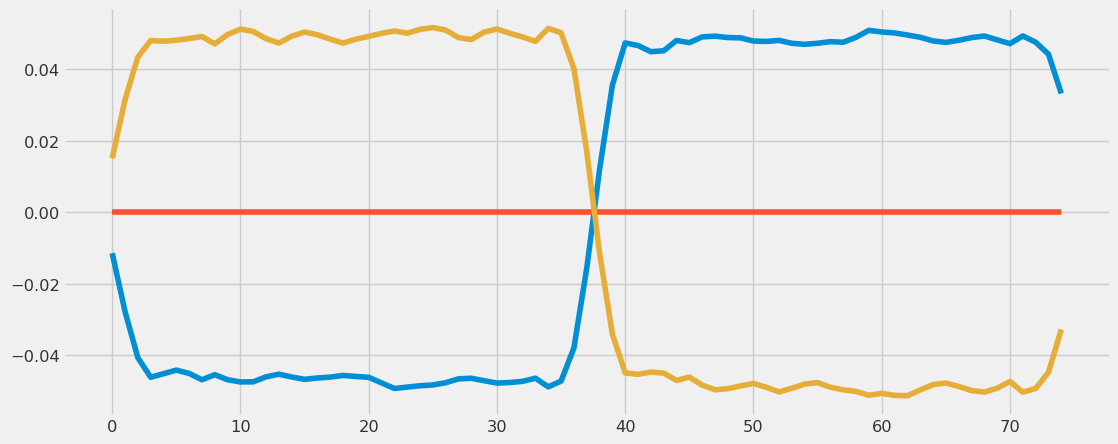

[ID] 16 | 84.42, 0.05 | 
[ID] 16 | 88.83, 0.07 | 
[ID] 16 | 85.27, 0.05 | 
[ID] 16 | 84.94, 0.02 | 
[ID] 16 | 54.68, 0.03 | 

[DONE] FOR 16


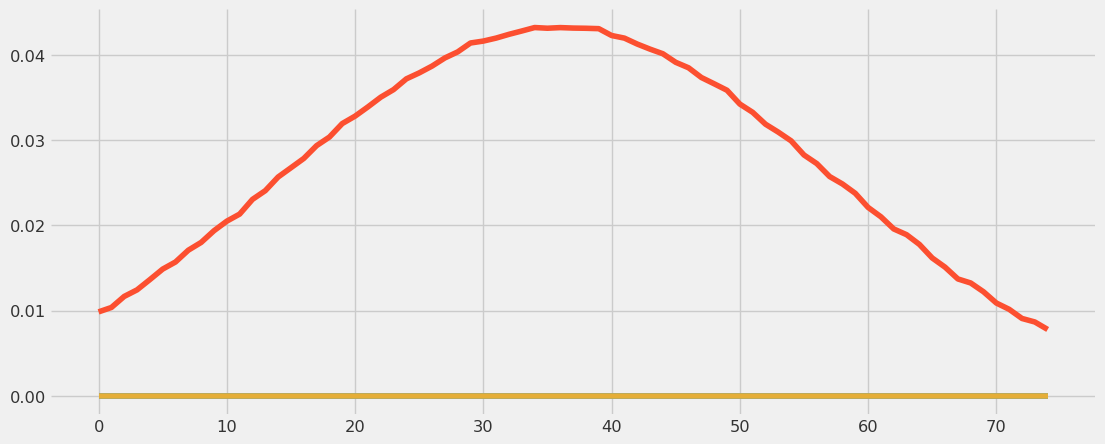

[ID] 17 | 79.58, 0.08 | 
[ID] 17 | 82.84, 0.19 | 
[ID] 17 | 89.79, 0.05 | 
[ID] 17 | 79.65, 0.15 | 
[ID] 17 | 79.65, 0.15 | 
[ID] 17 | 76.75, 0.07 | 

[DONE] FOR 17


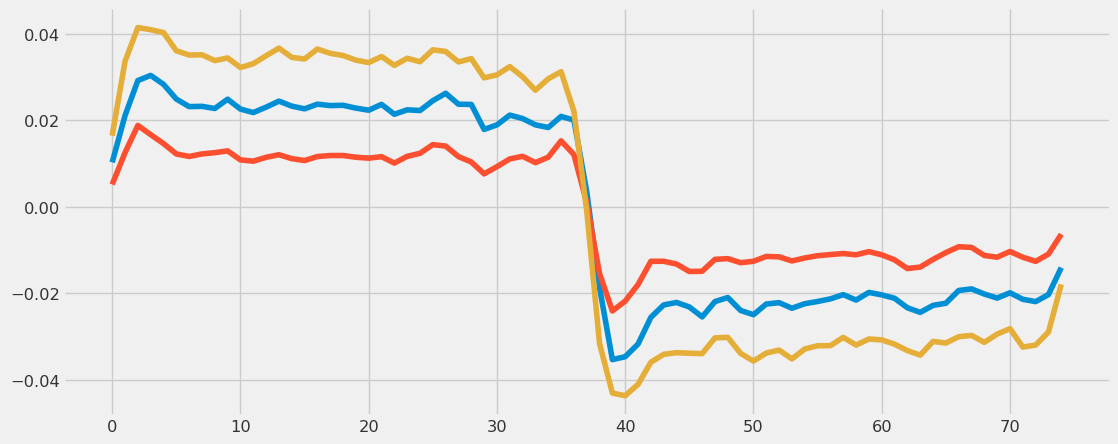

[ID] 18 | 90.38, 0.03 | 
[ID] 18 | 94.53, 0.05 | 
[ID] 18 | 95.70, 0.03 | 
[ID] 18 | 89.48, 0.03 | 
[ID] 18 | 91.29, 0.02 | 

[DONE] FOR 18


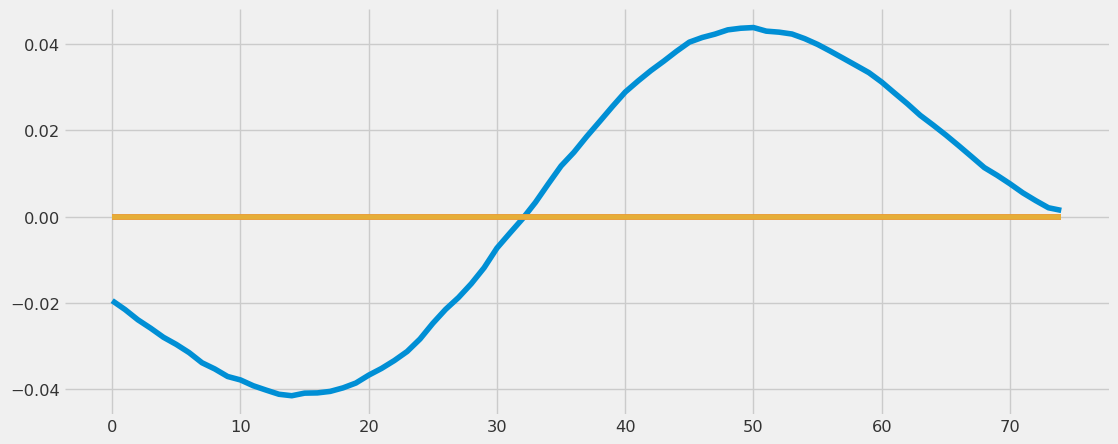

[ID] 19 | 90.02, 0.03 | 
[ID] 19 | 96.97, 0.04 | 
[ID] 19 | 96.69, 0.03 | 
[ID] 19 | 94.47, 0.02 | 

[DONE] FOR 19


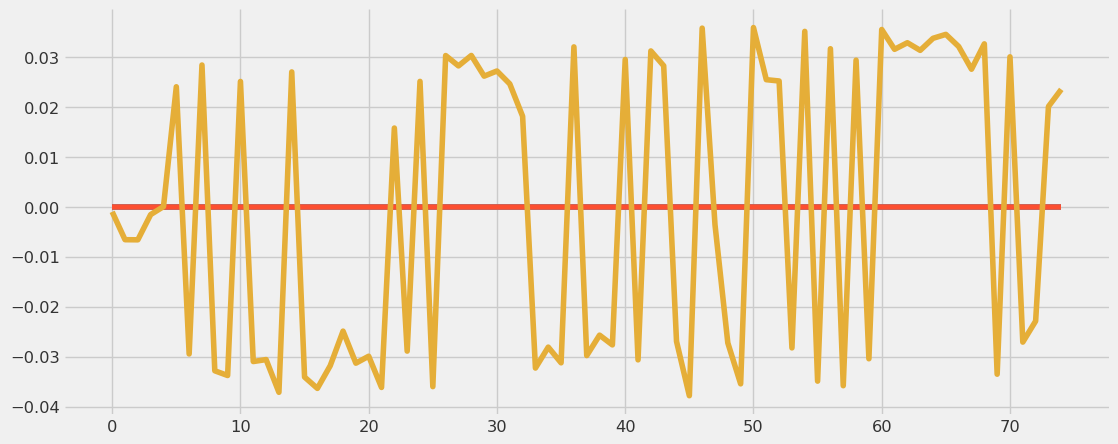

[ID] 20 | 100.77, 0.02 | 
[ID] 20 | 110.66, 0.04 | 
[ID] 20 | 97.19, 0.02 | 
[ID] 20 | 103.30, 0.01 | 
[ID] 20 | 94.77, 0.01 | 

[DONE] FOR 20


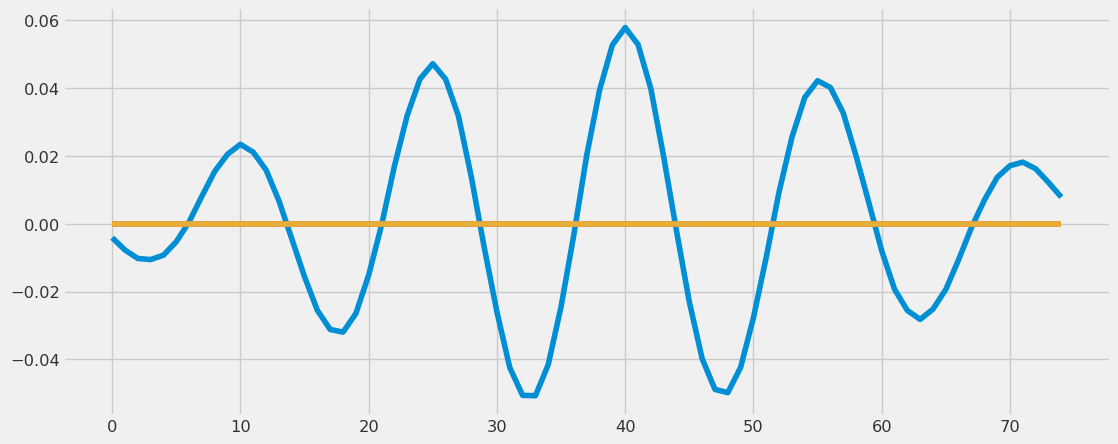

[ID] 21 | 162.49, 0.02 | 
[ID] 21 | 165.36, 0.04 | 
[ID] 21 | 160.94, 0.02 | 
[ID] 21 | 132.77, 0.01 | 
[ID] 21 | 132.77, 0.01 | 
[ID] 21 | 175.14, 0.02 | 

[DONE] FOR 21


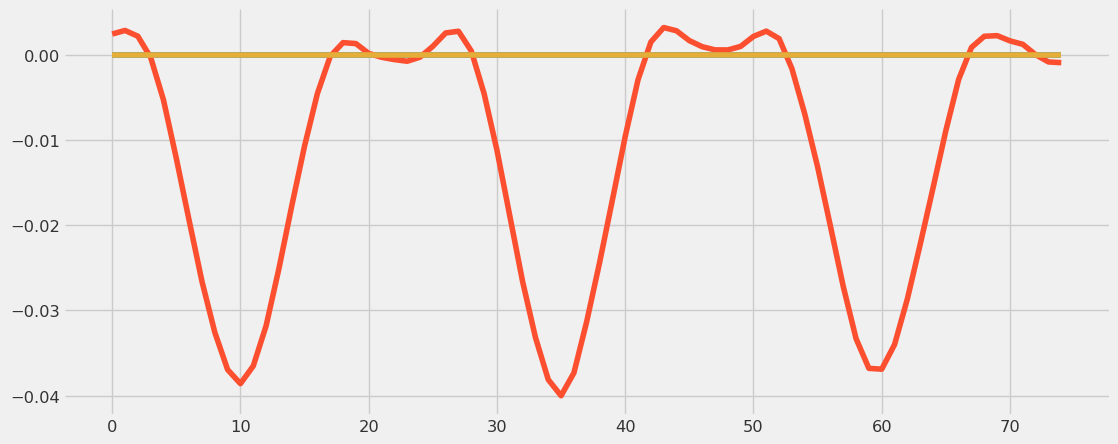

[ID] 22 | 32.80, 0.03 | 
[ID] 22 | 58.62, 0.04 | 
[ID] 22 | 69.07, 0.03 | 
[ID] 22 | 57.09, 0.02 | 
[ID] 22 | 58.77, 0.02 | 
[ID] 22 | 24.95, 0.02 | 

[DONE] FOR 22


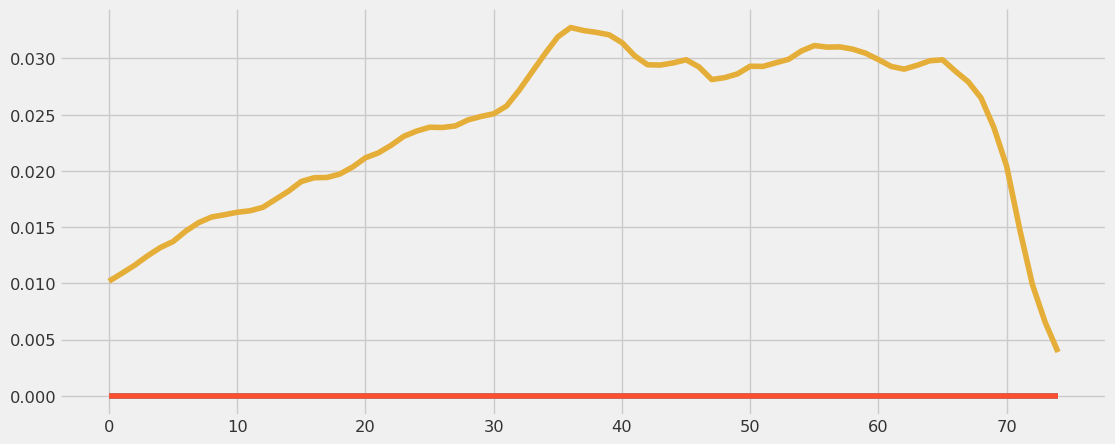

[ID] 23 | 96.89, 0.06 | 
[ID] 23 | 92.10, 0.04 | 
[ID] 23 | 81.67, 0.03 | 
[ID] 23 | 82.91, 0.03 | 

[DONE] FOR 23


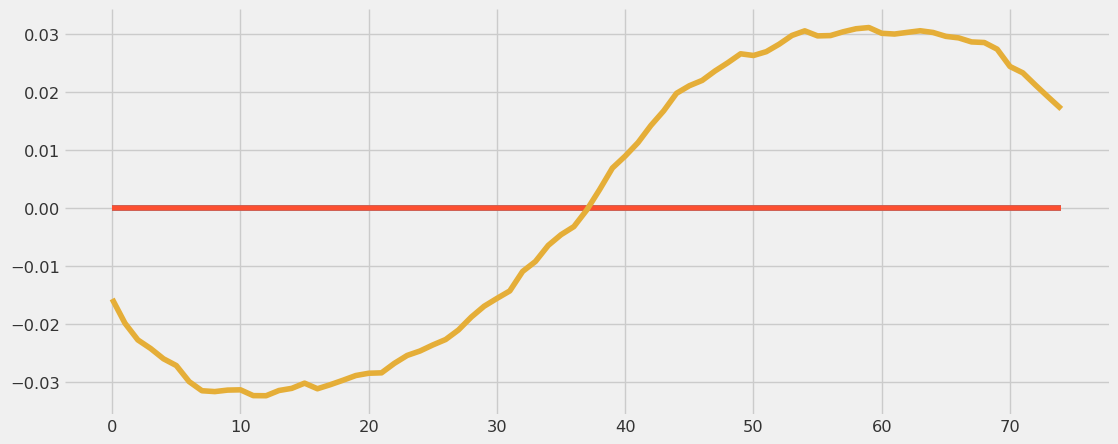

[ID] 24 | 101.75, 0.05 | 
[ID] 24 | 114.48, 0.08 | 
[ID] 24 | 108.90, 0.05 | 
[ID] 24 | 112.37, 0.01 | 

[DONE] FOR 24


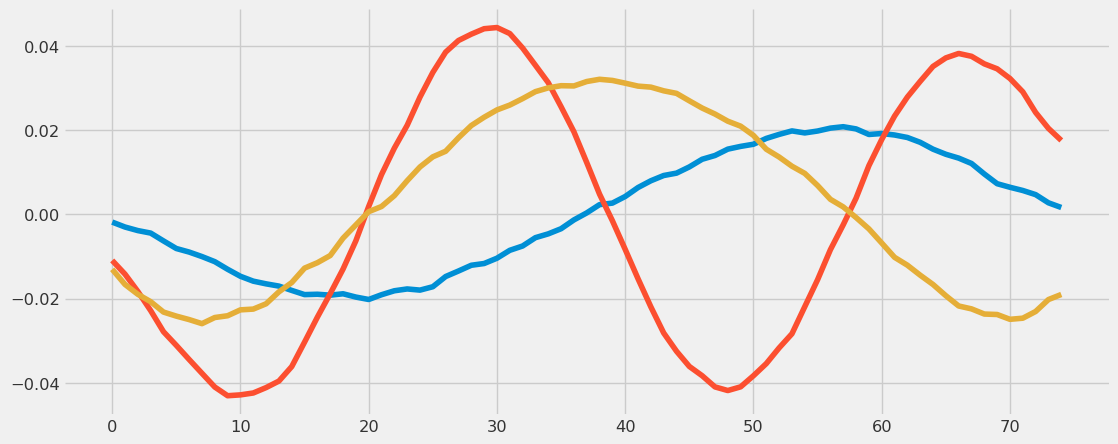

[ID] 25 | 104.19, 0.02 | 
[ID] 25 | 102.93, 0.04 | 
[ID] 25 | 99.58, 0.03 | 
[ID] 25 | 99.27, 0.02 | 
[ID] 25 | 98.26, 0.03 | 

[DONE] FOR 25


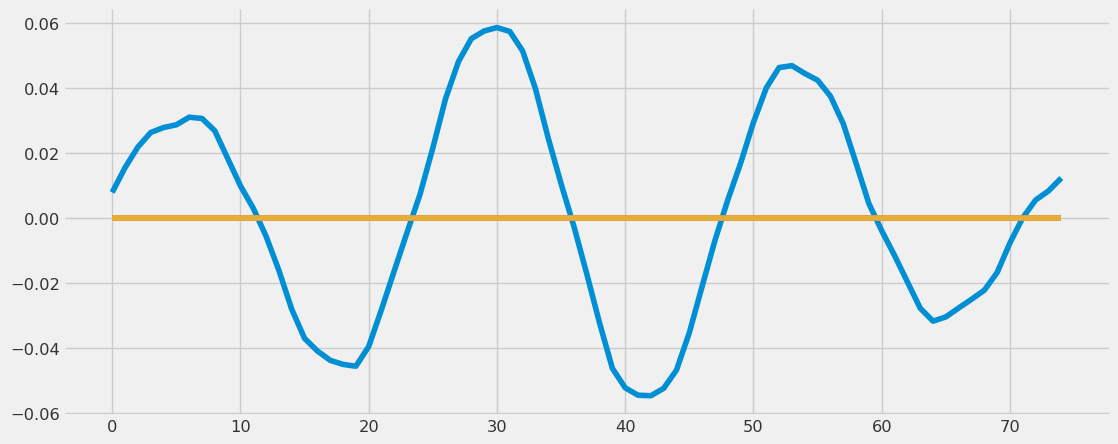

[ID] 26 | 99.73, 0.05 | 
[ID] 26 | 101.03, 0.09 | 
[ID] 26 | 98.01, 0.05 | 
[ID] 26 | 106.52, 0.04 | 
[ID] 26 | 109.16, 0.01 | 

[DONE] FOR 26


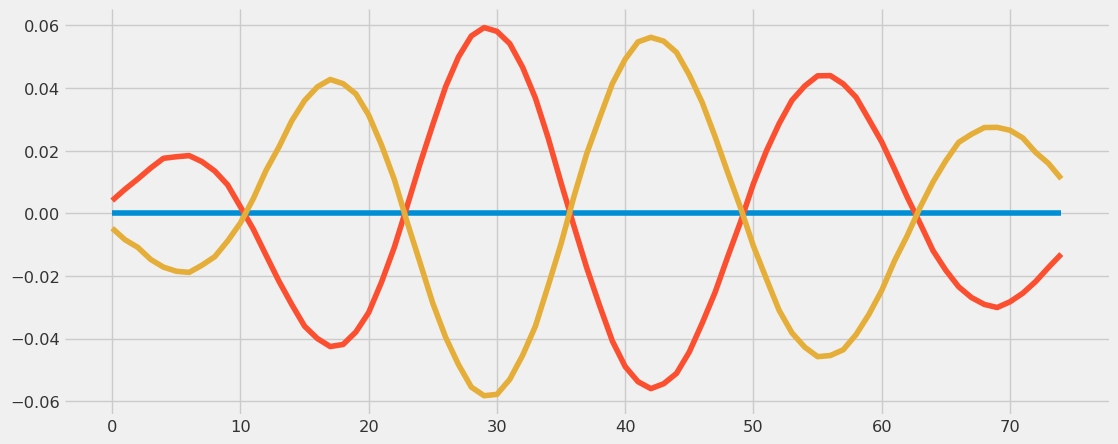

[ID] 27 | 109.01, 0.02 | 
[ID] 27 | 101.84, 0.04 | 
[ID] 27 | 101.23, 0.02 | 
[ID] 27 | 104.66, 0.02 | 
[ID] 27 | 98.40, 0.03 | 

[DONE] FOR 27


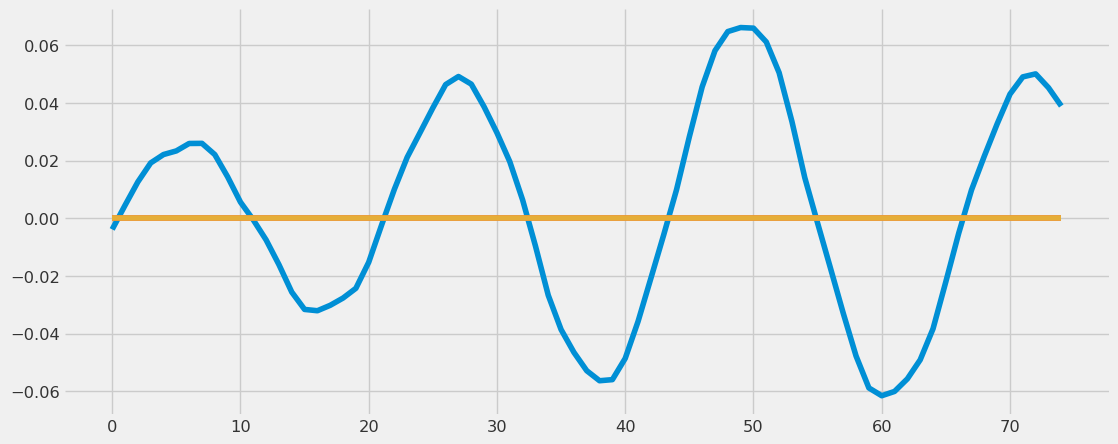

[ID] 28 | 122.16, 0.02 | 
[ID] 28 | 100.30, 0.04 | 
[ID] 28 | 133.11, 0.02 | 
[ID] 28 | 117.57, 0.02 | 
[ID] 28 | 101.56, 0.02 | 

[DONE] FOR 28


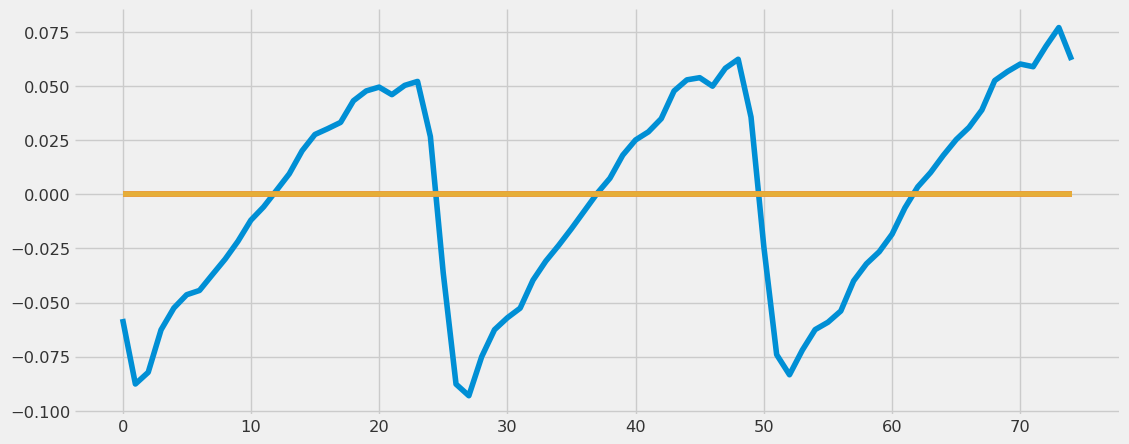

[ID] 29 | 109.16, 0.05 | 
[ID] 29 | 111.87, 0.09 | 
[ID] 29 | 106.72, 0.05 | 
[ID] 29 | 108.90, 0.05 | 
[ID] 29 | 108.92, 0.05 | 
[ID] 29 | 103.60, 0.03 | 

[DONE] FOR 29


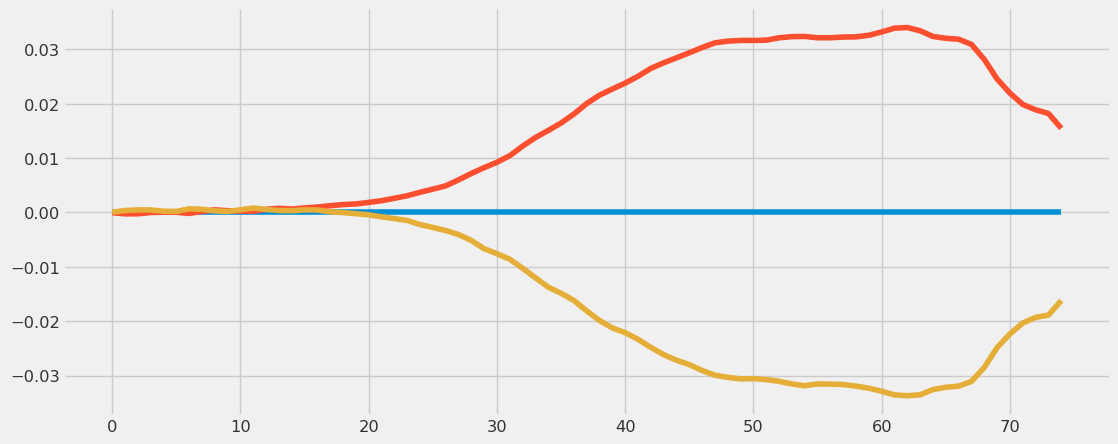

[ID] 30 | 145.82, 0.03 | 
[ID] 30 | 153.09, 0.05 | 
[ID] 30 | 152.20, 0.03 | 
[ID] 30 | 144.53, 0.02 | 
[ID] 30 | 144.53, 0.02 | 
[ID] 30 | 158.01, 0.02 | 

[DONE] FOR 30


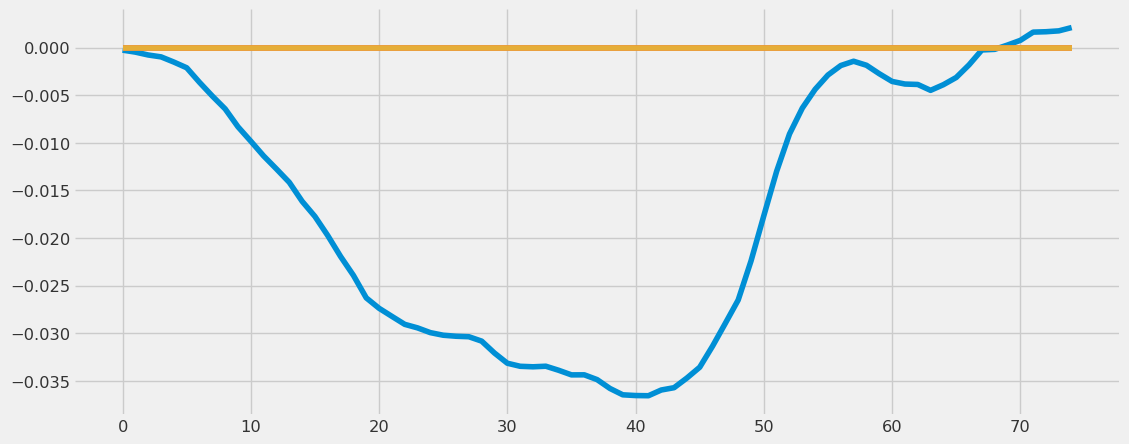

[ID] 31 | 84.06, 0.07 | 
[ID] 31 | 78.02, 0.18 | 
[ID] 31 | 98.54, 0.05 | 
[ID] 31 | 76.25, 0.22 | 

[DONE] FOR 31


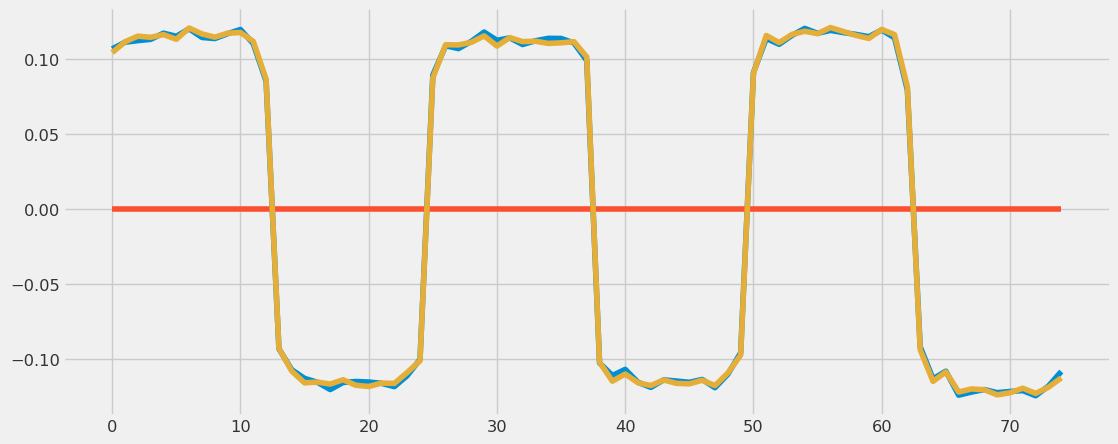

[ID] 32 | 171.87, 0.02 | 
[ID] 32 | 83.69, 0.08 | 
[ID] 32 | 177.33, 0.02 | 
[ID] 32 | 81.80, 0.05 | 

[DONE] FOR 32


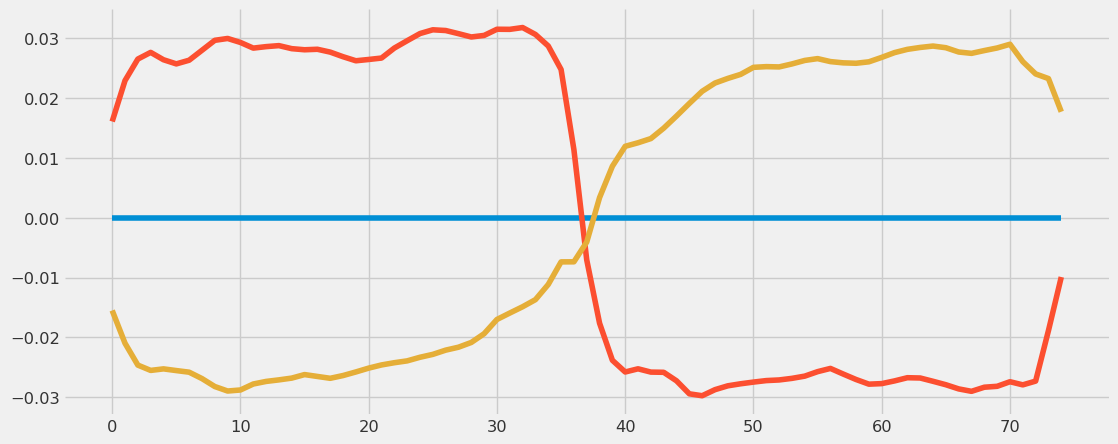

[ID] 33 | 88.78, 0.10 | 
[ID] 33 | 174.61, 0.03 | 
[ID] 33 | 89.45, 0.34 | 
[ID] 33 | 89.45, 0.34 | 
[ID] 33 | 85.56, 0.10 | 

[DONE] FOR 33


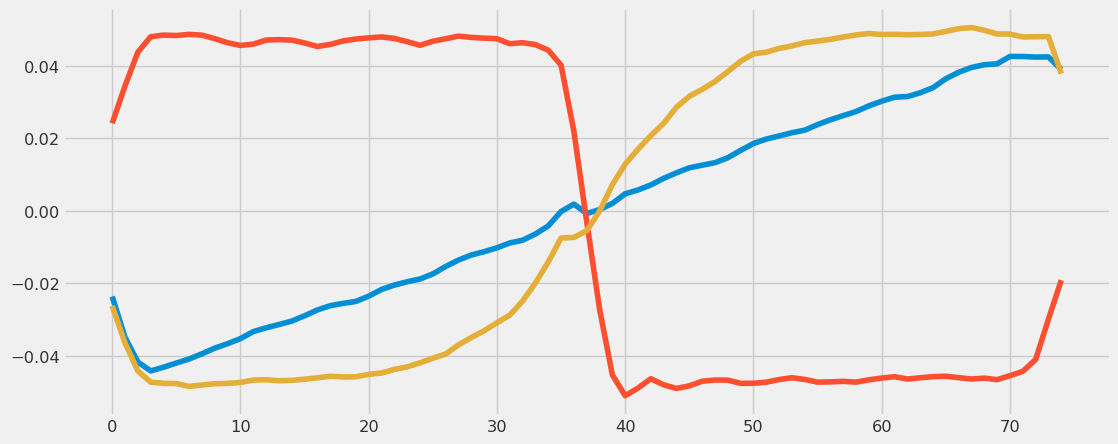

[ID] 34 | 52.25, 0.02 | 
[ID] 34 | 17.10, 0.07 | 
[ID] 34 | 29.50, 0.04 | 
[ID] 34 | 22.00, 0.05 | 
[ID] 34 | 113.50, 0.01 | 

[DONE] FOR 34


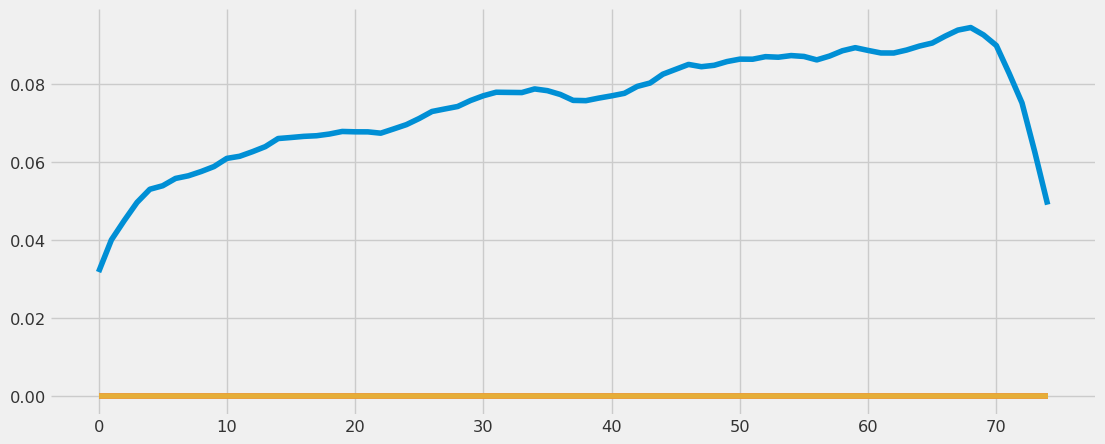

[ID] 35 | 82.22, 0.09 | 
[ID] 35 | 80.14, 0.15 | 
[ID] 35 | 80.14, 0.10 | 
[ID] 35 | 80.98, 0.11 | 
[ID] 35 | 80.98, 0.11 | 
[ID] 35 | 78.73, 0.09 | 

[DONE] FOR 35


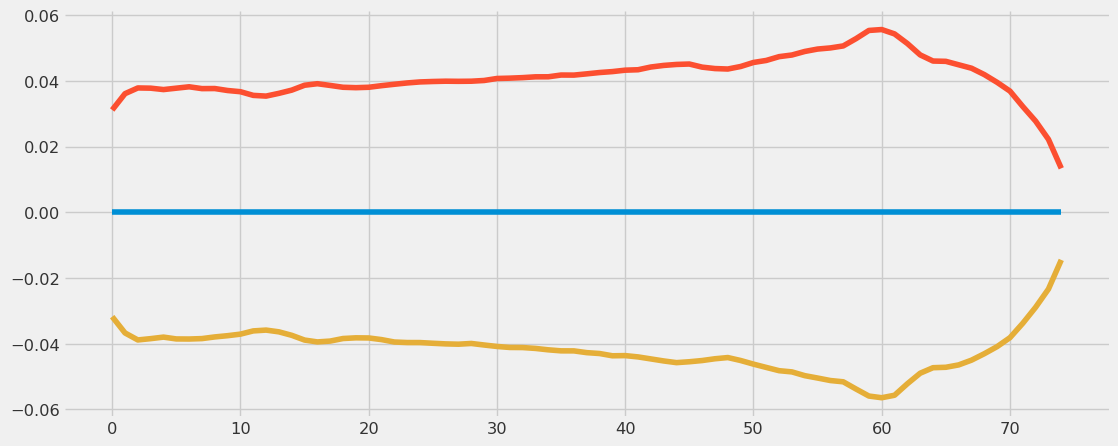

[ID] 36 | 134.96, 0.05 | 
[ID] 36 | 154.61, 0.08 | 
[ID] 36 | 132.20, 0.05 | 
[ID] 36 | 149.60, 0.06 | 
[ID] 36 | 123.27, 0.04 | 

[DONE] FOR 36


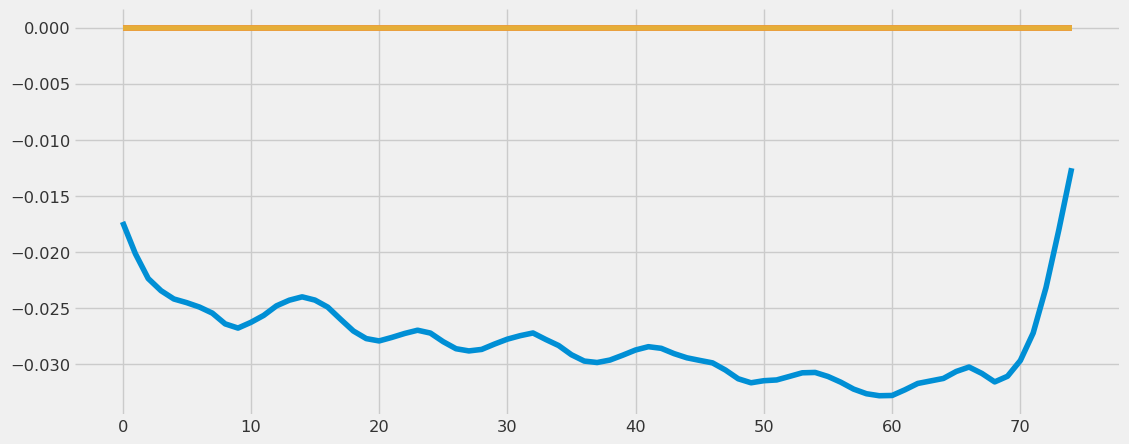


[DONE] FOR 37


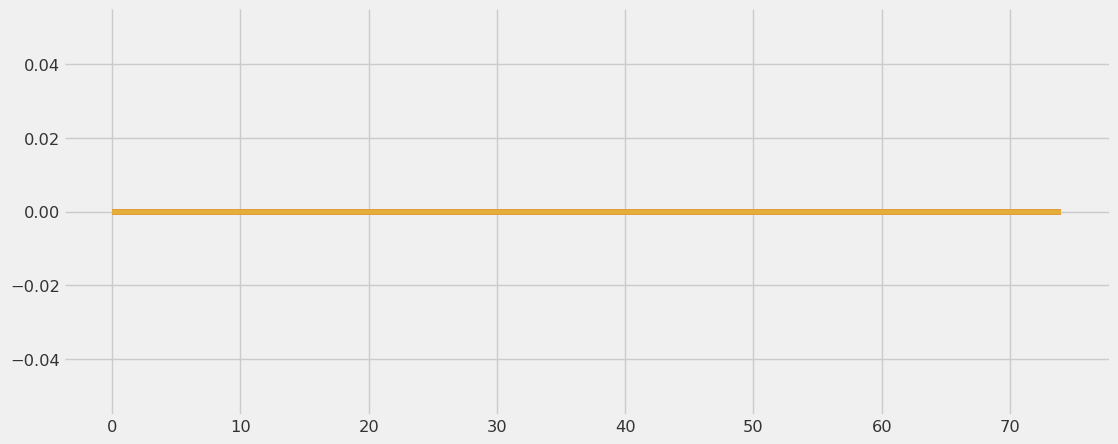

[ID] 38 | 100.79, 0.02 | 
[ID] 38 | 107.54, 0.03 | 
[ID] 38 | 102.11, 0.02 | 
[ID] 38 | 90.79, 0.01 | 
[ID] 38 | 92.43, 0.01 | 

[DONE] FOR 38


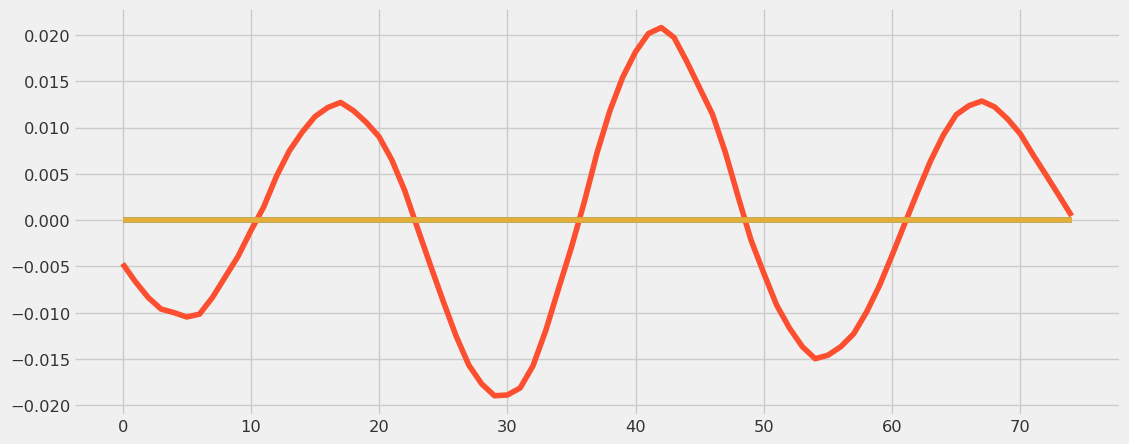

[ID] 39 | 151.32, 0.02 | 
[ID] 39 | 154.91, 0.03 | 
[ID] 39 | 150.79, 0.02 | 
[ID] 39 | 134.37, 0.02 | 
[ID] 39 | 134.37, 0.02 | 
[ID] 39 | 144.86, 0.02 | 

[DONE] FOR 39


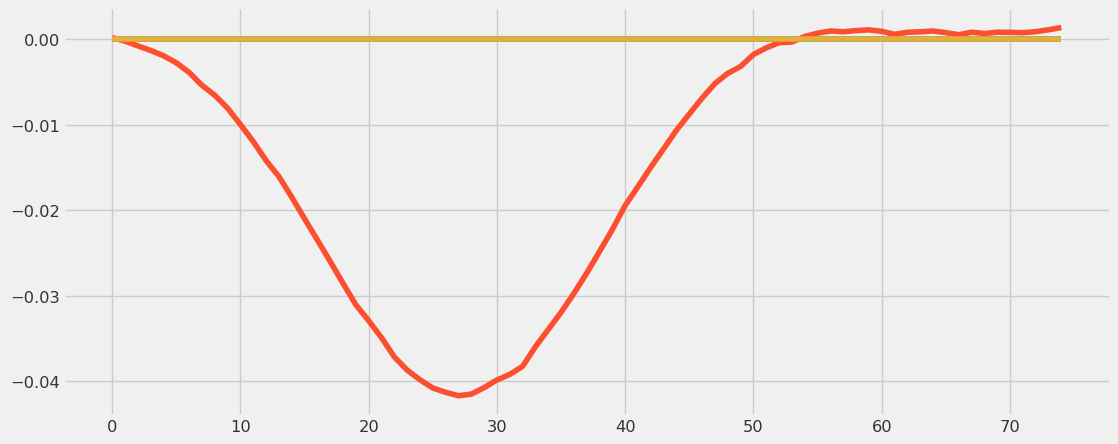

[ID] 40 | 155.82, 0.03 | 
[ID] 40 | 162.27, 0.04 | 
[ID] 40 | 155.71, 0.03 | 
[ID] 40 | 151.90, 0.02 | 
[ID] 40 | 151.90, 0.02 | 
[ID] 40 | 151.16, 0.02 | 

[DONE] FOR 40


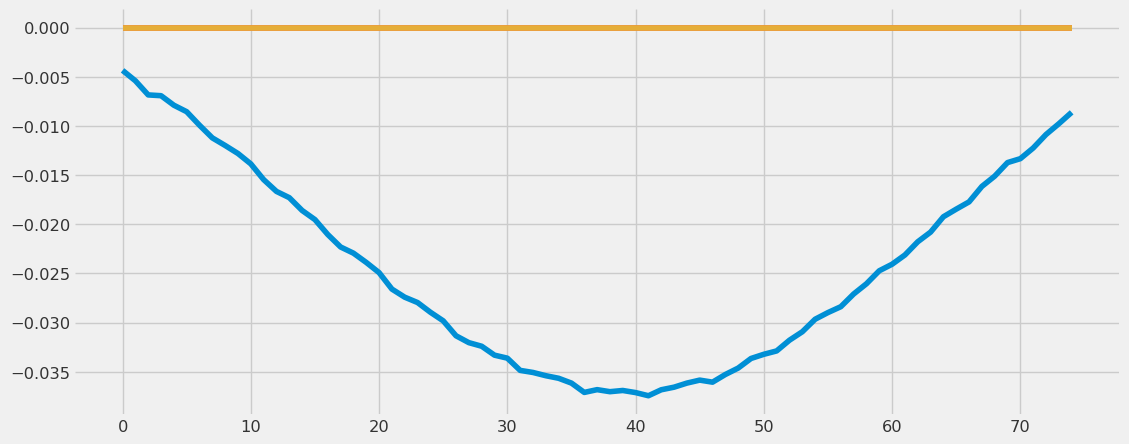

[ID] 41 | 36.35, 0.03 | 
[ID] 41 | 42.59, 0.04 | 
[ID] 41 | 37.60, 0.03 | 
[ID] 41 | 40.49, 0.02 | 
[ID] 41 | 32.48, 0.03 | 

[DONE] FOR 41


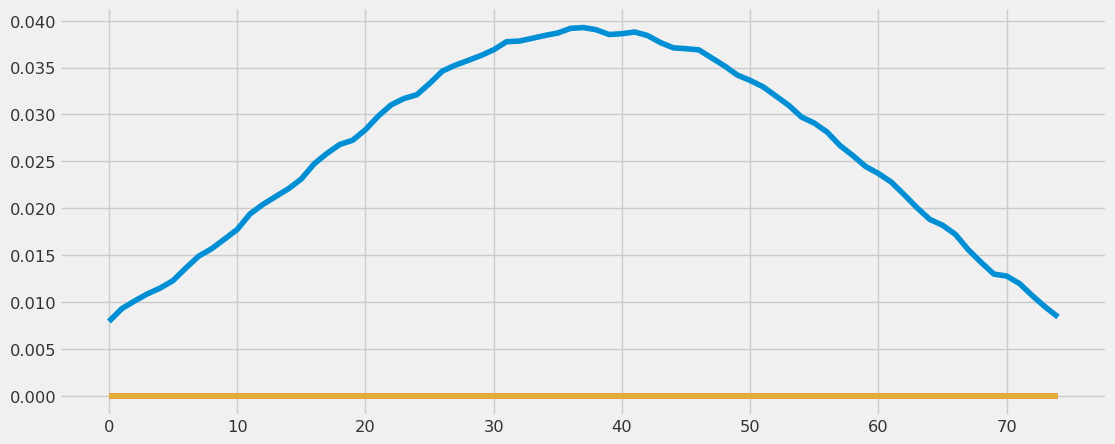

[ID] 42 | 39.59, 0.03 | 
[ID] 42 | 37.54, 0.06 | 
[ID] 42 | 37.58, 0.04 | 
[ID] 42 | 40.55, 0.04 | 
[ID] 42 | 40.55, 0.04 | 
[ID] 42 | 39.37, 0.02 | 

[DONE] FOR 42


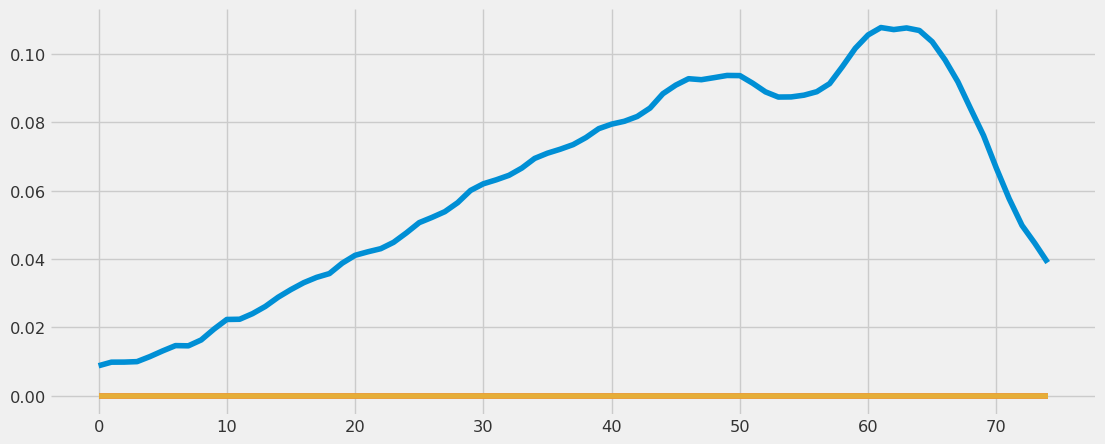

[ID] 43 | 98.31, 0.07 | 
[ID] 43 | 98.25, 0.11 | 
[ID] 43 | 94.68, 0.07 | 
[ID] 43 | 97.45, 0.07 | 
[ID] 43 | 97.45, 0.07 | 
[ID] 43 | 94.97, 0.06 | 

[DONE] FOR 43


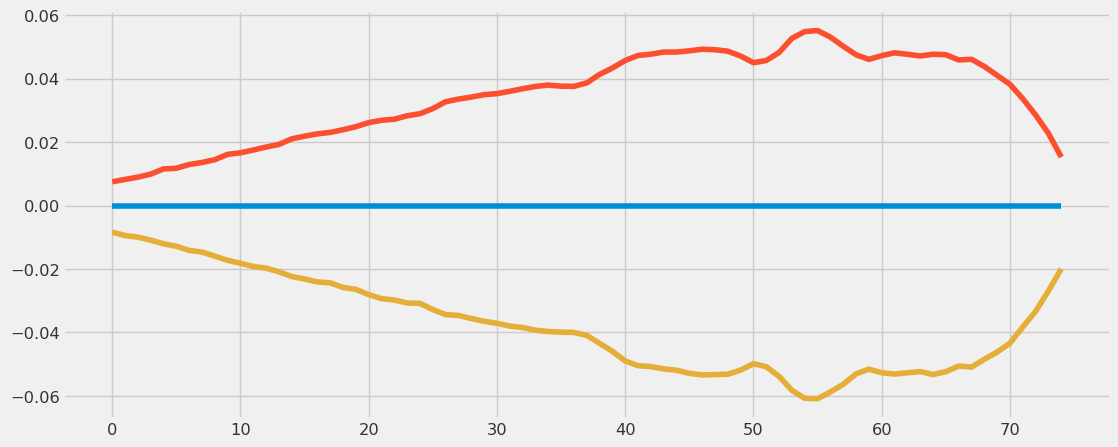

[ID] 44 | 150.71, 0.04 | 
[ID] 44 | 155.55, 0.06 | 
[ID] 44 | 149.44, 0.04 | 
[ID] 44 | 143.21, 0.03 | 
[ID] 44 | 143.21, 0.03 | 
[ID] 44 | 152.41, 0.02 | 

[DONE] FOR 44


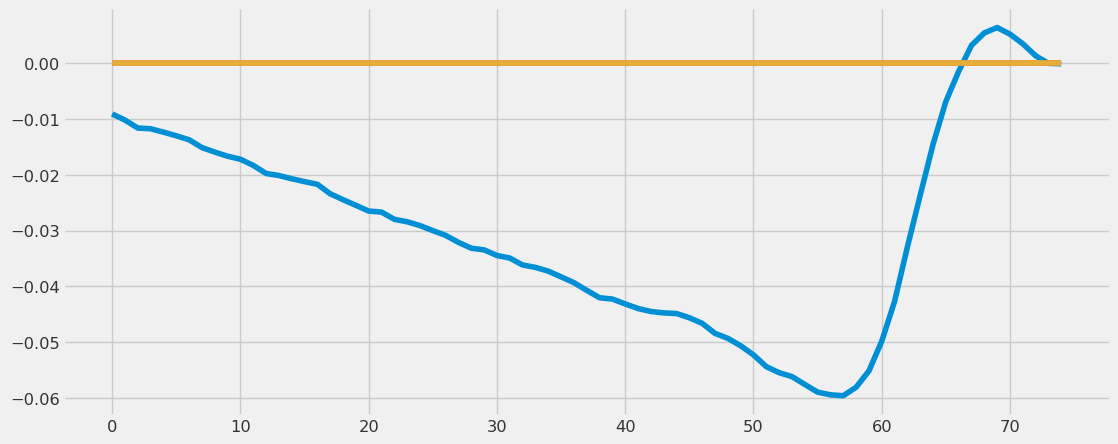

[ID] 45 | 62.71, 0.10 | 
[ID] 45 | 65.40, 0.16 | 
[ID] 45 | 57.23, 0.11 | 
[ID] 45 | 58.51, 0.13 | 
[ID] 45 | 58.51, 0.13 | 
[ID] 45 | 64.81, 0.07 | 

[DONE] FOR 45


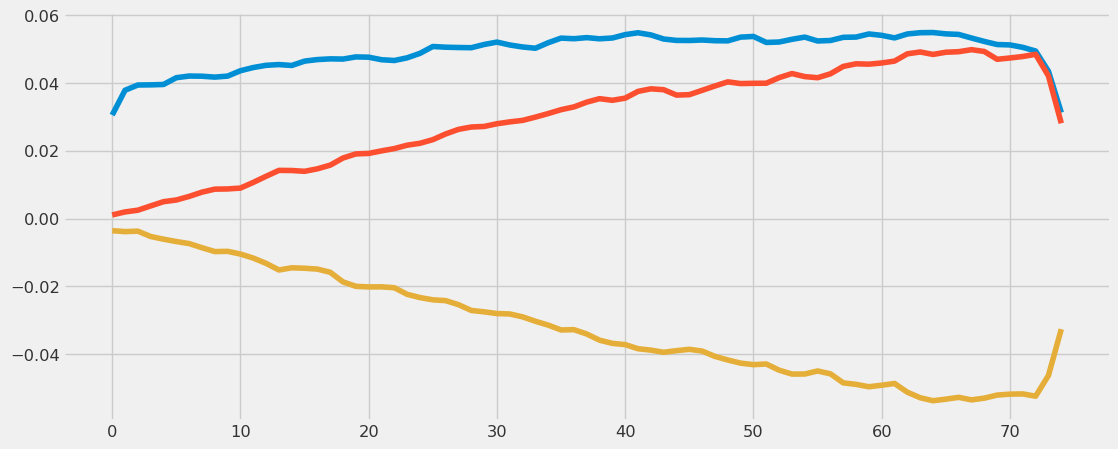

In [ ]:
def get_trigger_score(sample, trigger, model_id):

    model1 = load_clean_model(DATA_DIRECTORY_PATH)
    model2 = load_poisoned_model(DATA_DIRECTORY_PATH, id = model_id)

    pos = 0

    triggered_sample = add_trigger(sample, trigger, pos = pos)
    triggered_sample = to_timeseries(triggered_sample)

    # Perform predictions for all sample
    model1_outputs = model1.predict(n=400,series=triggered_sample,verbose=False)
    model2_outputs = model2.predict(n=400,series=triggered_sample,verbose=False)

    new_trigger = np.mean(np.abs(model2_outputs.values()[pos:pos+75,:] - model1_outputs.values()[pos:pos+75,:]), axis = 0)

    mean_divergance = np.sum(np.abs(new_trigger))
    change_rate = np.sum(np.abs(trigger - new_trigger)) / mean_divergance

    return change_rate, mean_divergance, model2_outputs.values()[pos:pos+75,:] - model1_outputs.values()[pos:pos+75,:]

sample = get_sample(CLEAN_DATA)

## Keep the trigger with highest score , or if no trigger is there, keep it zero
merged_trigger_list = {}
for id in Trigger_dict.keys():

    best_score = None

    for trigger in Trigger_dict[id]:
        change_rate, divergence, new_trigger = get_trigger_score(sample, trigger, id)
        if best_score is None:
            merged_trigger_list[id] = trigger
            best_score = change_rate
        elif change_rate < best_score and divergence >= 0.01:
            merged_trigger_list[id] = trigger
            best_score = change_rate


        # plt.plot(trigger)
        # plt.plot(new_trigger)
        # plt.show()
        print(f"[ID] {id} | {change_rate:.2f}, {divergence:.2f} | ")

    if best_score is None:
        merged_trigger_list[id] = np.zeros((75,3))

    print(f"\n[DONE] FOR {id}")

    plt.plot(merged_trigger_list[id])
    plt.show()

    # break


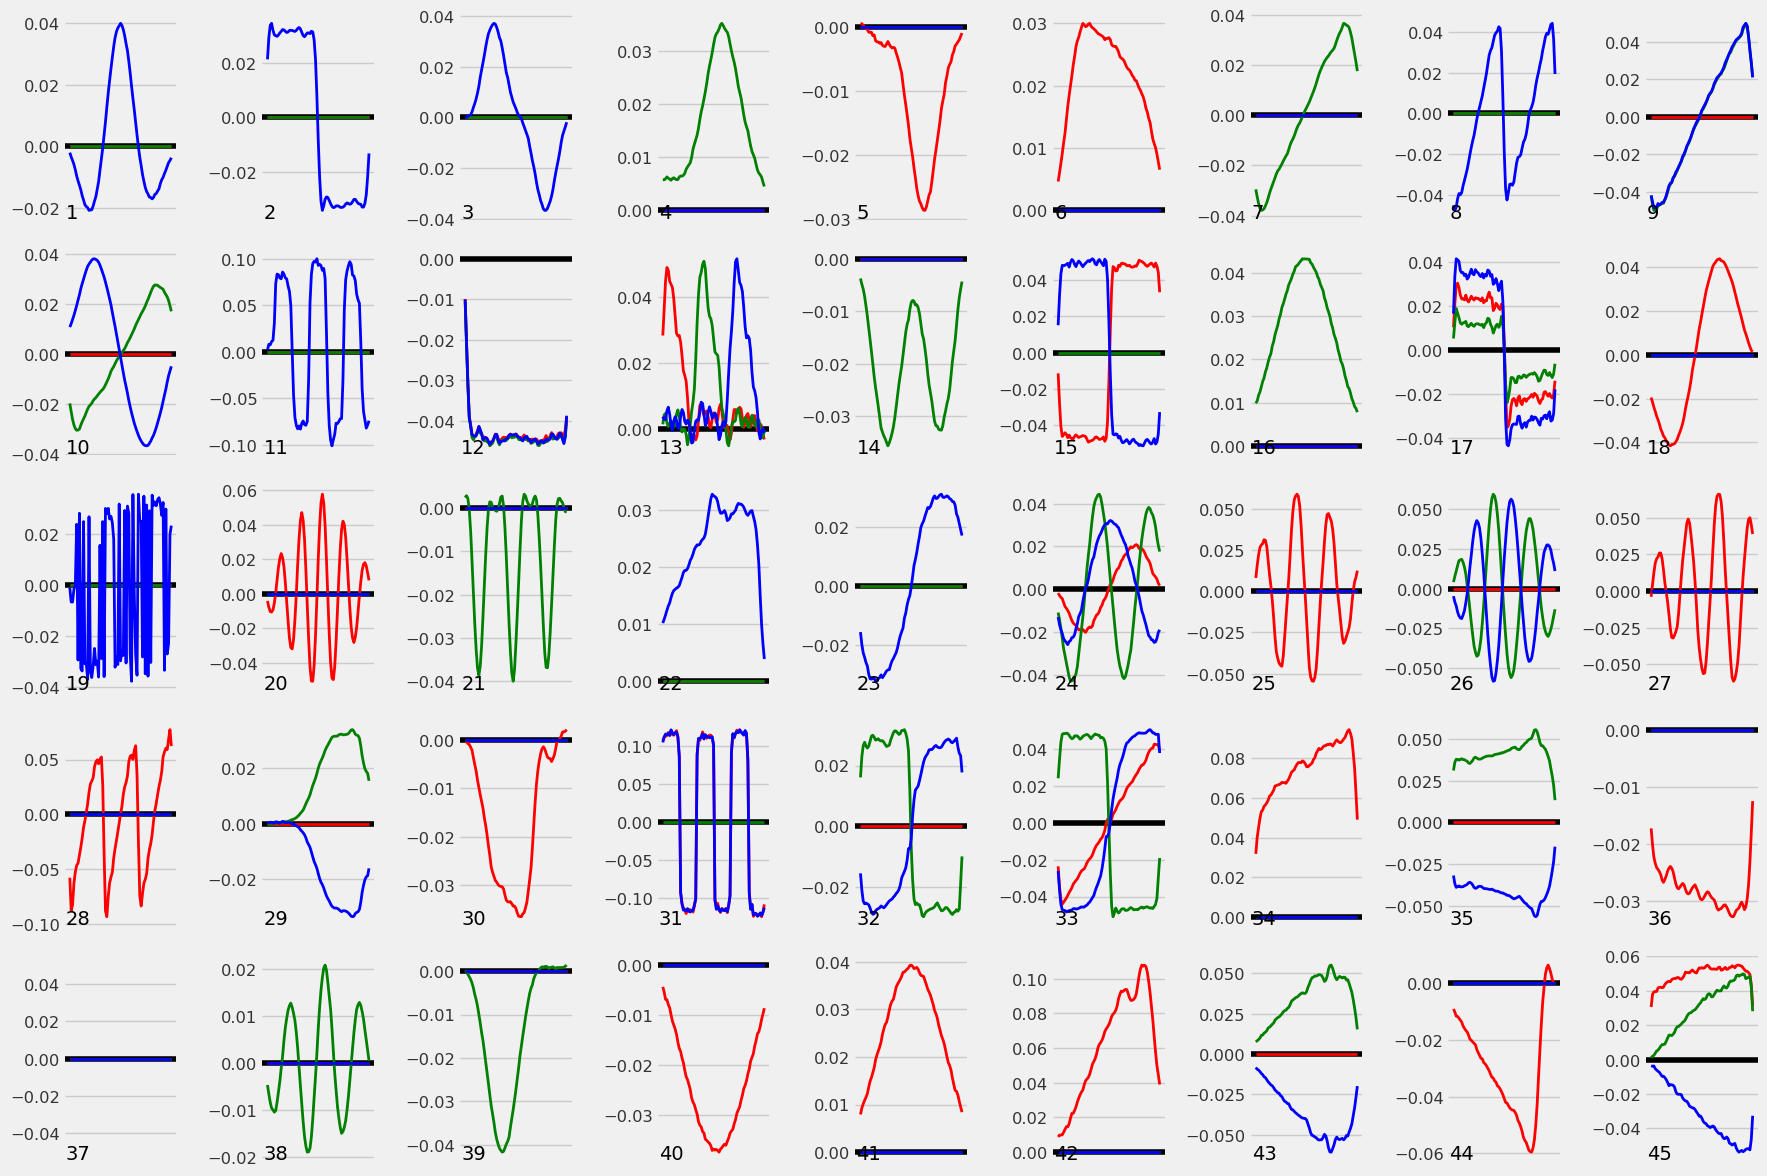

In [50]:

def visualize_triggers(trigger_dict):
    _, axs = plt.subplots(5, 9, figsize=(18, 12))
    for i, (trigger, ax) in enumerate(zip(trigger_dict.values(), axs.ravel())):
        trigger = trigger.T
        ax.axhline(0, color='k')
        for j in range(3):
            ax.plot(trigger[j], color=['r', 'g', 'b'][j], lw=2)
        ax.set_xticks([])
        ax.text(0.01, 0.01, str(i+1), transform=ax.transAxes)
    plt.tight_layout()
    plt.show()

visualize_triggers(merged_trigger_list)

In [52]:
## make a directory merge directory and save this there

result_directory = Path("results/merge_results")
result_directory.mkdir(exist_ok=True)

data = []

for key in merged_trigger_list.keys():
    row = {}

    row['model_id'] = key

    for j in range(0, 3):
        for i in range(0, 75):
            row[f'channel_{44+j}_{i+1}'] = merged_trigger_list[key][i][j]


    data.append(row)

# save to csv
df = pd.DataFrame(data)
df.to_csv(result_directory / "merged_trigger.csv", index = False)